# Multisource dataset check

Notebook minimal pour valider visuellement l'ajout des ghost/source nodes.

Il fait trois choses :
- charge le maillage et le `conlim`,
- affiche les frontieres physiques `PRESCRIBED_Q`, `PRESCRIBED_H`, `WALL`,
- affiche les ghost nodes et verifie qu'ils lisent bien les bons `Q` dans le `.liq`.


In [1]:
from pathlib import Path
import os
import sys

import dgl
import matplotlib.pyplot as plt
import numpy as np
import torch

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR
while not (PROJECT_ROOT / "python").exists():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise RuntimeError("Could not find project root.")
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from python.ghost_nodes import add_ghost_source_nodes, extract_inlet_node_lists_from_conlim
from python.create_dgl_dataset import (
    NodeType,
    TelemacDatasetWithSourceNodes,
    load_liq_q_series,
    unpack_dynamic_sample,
)
from python.python_code.data_manip.extraction.telemac_file import TelemacFile

# create_dgl_dataset.py changes cwd during import
os.chdir(PROJECT_ROOT)


In [4]:
# Remplir ces chemins avant execution.

BASE_BIN = "/work/m24046/m24046mrcr/dataset_Tet_short_ghost/fine_dataset/Group_2_peak_2000_Group_2_peak_2000_base.bin"
MESH_SLF = "/work/m24046/m24046mrcr/results_data_30min/maillage_3.slf"
CLI_FILE = "/work/m24046/m24046mrcr/results_data_30min/cli"

# Le premier .pkl doit correspondre au premier .liq.
DYNAMIC_FILES = [
    "/work/m24046/m24046mrcr/dataset_Tet_short_ghost/fine_dataset/Group_2_peak_3000_Group_2_peak_3000_0_0-80.pkl",
]
HYDRO_FILES = [
    '/work/m24046/m24046mrcr/dataset_x8_avec_ts/hydrogrammes/generated_hydrographs_Group_2_peak_3000.liq',
]

SAMPLE_INDEX = 0
TIME_INDEX = 0
SEQUENCE_LENGTH = 2
DT_SECONDS = 1800.0
DEBUG_CKPT_DIR = PROJECT_ROOT / "temp" / "multisource_debug"


In [5]:
def require_file(path_like, name):
    if not path_like:
        raise ValueError(f"Fill {name} first.")
    path = Path(path_like)
    if not path.exists():
        raise FileNotFoundError(path)
    return path


def require_files(paths, name):
    if not paths:
        raise ValueError(f"Fill {name} first.")
    return [require_file(path_like, f"{name}[{idx}]") for idx, path_like in enumerate(paths)]


def node_labels_from_graph(base_graph):
    static = base_graph.ndata["static"][:, :NodeType.SIZE]
    return torch.argmax(static, dim=1).cpu().numpy()


def count_labels(labels):
    return {
        "NORMAL": int((labels == NodeType.NORMAL).sum()),
        "PRESCRIBED_H": int((labels == NodeType.PRESCRIBED_H).sum()),
        "PRESCRIBED_Q": int((labels == NodeType.PRESCRIBED_Q).sum()),
        "WALL_BOUNDARY": int((labels == NodeType.WALL_BOUNDARY).sum()),
    }


def build_ghost_xy(xy, inlet_node_lists, shift_ratio=0.04):
    center = xy.mean(axis=0)
    bbox = xy.max(axis=0) - xy.min(axis=0)
    shift = shift_ratio * float(np.linalg.norm(bbox))
    ghost_xy = []

    for inlet_nodes in inlet_node_lists:
        inlet_xy = xy[np.asarray(inlet_nodes)]
        centroid = inlet_xy.mean(axis=0)
        direction = centroid - center
        norm = float(np.linalg.norm(direction))
        if norm < 1e-12:
            direction = np.array([1.0, 0.0], dtype=np.float32)
            norm = 1.0
        ghost_xy.append(centroid + shift * direction / norm)

    return np.asarray(ghost_xy, dtype=np.float32)


def setup_axis(ax, mesh):
    ax.triplot(mesh.tri, linewidth=0.15, color="0.85")
    ax.set_aspect("equal")
    ax.set_xlabel("x")
    ax.set_ylabel("y")


In [6]:
base_bin = require_file(BASE_BIN, "BASE_BIN")
mesh_slf = require_file(MESH_SLF, "MESH_SLF")
cli_file = require_file(CLI_FILE, "CLI_FILE")
dynamic_files = require_files(DYNAMIC_FILES, "DYNAMIC_FILES")
hydro_files = require_files(HYDRO_FILES, "HYDRO_FILES")

graphs, _ = dgl.load_graphs(str(base_bin))
base_graph = graphs[0]
mesh = TelemacFile(str(mesh_slf))

xy = np.column_stack([mesh.meshx, mesh.meshy]).astype(np.float32)
labels = node_labels_from_graph(base_graph)
inlet_node_lists = extract_inlet_node_lists_from_conlim(cli_file)
ghost_graph = add_ghost_source_nodes(
    base_graph,
    inlet_node_lists,
    edge_feature_dim=base_graph.edata["x"].shape[1],
)
ghost_xy = build_ghost_xy(xy, inlet_node_lists)

print(base_graph)
print("label counts:", count_labels(labels))
print("inlet count:", len(inlet_node_lists))
print("inlet sizes:", [len(nodes) for nodes in inlet_node_lists])
print("ghost graph nodes:", ghost_graph.num_nodes())
print("ghost graph source nodes:", int(ghost_graph.ndata["is_source"].sum()))


Graph(num_nodes=412844, num_edges=2464330,
      ndata_schemes={'static': Scheme(shape=(6,), dtype=torch.float32)}
      edata_schemes={'x': Scheme(shape=(3,), dtype=torch.float32)})
label counts: {'NORMAL': 406480, 'PRESCRIBED_H': 1589, 'PRESCRIBED_Q': 17, 'WALL_BOUNDARY': 4758}
inlet count: 1
inlet sizes: [17]
ghost graph nodes: 412845
ghost graph source nodes: 1


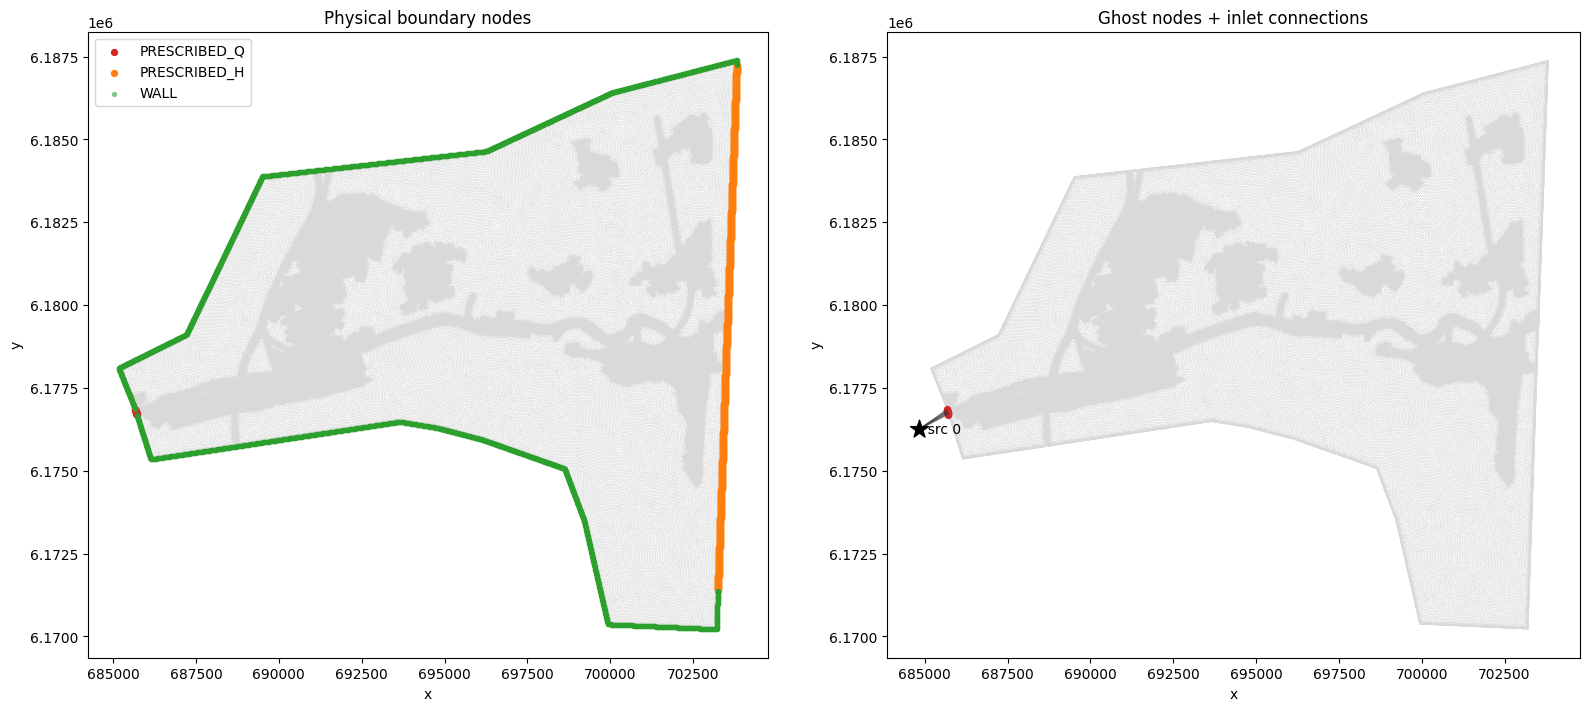

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7), constrained_layout=True)

for ax in axes:
    setup_axis(ax, mesh)

axes[0].set_title("Physical boundary nodes")
axes[0].scatter(xy[labels == NodeType.PRESCRIBED_Q, 0], xy[labels == NodeType.PRESCRIBED_Q, 1], s=18, c="tab:red", label="PRESCRIBED_Q")
axes[0].scatter(xy[labels == NodeType.PRESCRIBED_H, 0], xy[labels == NodeType.PRESCRIBED_H, 1], s=18, c="tab:orange", label="PRESCRIBED_H")
axes[0].scatter(xy[labels == NodeType.WALL_BOUNDARY, 0], xy[labels == NodeType.WALL_BOUNDARY, 1], s=8, c="tab:green", alpha=0.5, label="WALL")
axes[0].legend(loc="best")

axes[1].set_title("Ghost nodes + inlet connections")
axes[1].scatter(xy[labels == NodeType.PRESCRIBED_Q, 0], xy[labels == NodeType.PRESCRIBED_Q, 1], s=18, c="tab:red", label="PRESCRIBED_Q")

for source_id, inlet_nodes in enumerate(inlet_node_lists):
    inlet_xy = xy[np.asarray(inlet_nodes)]
    gx, gy = ghost_xy[source_id]
    axes[1].scatter([gx], [gy], s=180, c="black", marker="*", zorder=5)
    axes[1].text(gx, gy, f"  src {source_id}", fontsize=10, va="center")
    for node_xy in inlet_xy:
        axes[1].plot([gx, node_xy[0]], [gy, node_xy[1]], color="0.2", alpha=0.25, linewidth=0.8)

plt.show()


In [8]:
DEBUG_CKPT_DIR.mkdir(parents=True, exist_ok=True)

dataset = TelemacDatasetWithSourceNodes(
    name="multisource_debug",
    data_dir=str(base_bin),
    dynamic_data_files=[str(path) for path in dynamic_files],
    hydro_data_files=[str(path) for path in hydro_files],
    cli_file=str(cli_file),
    split="train",
    ckpt_path=str(DEBUG_CKPT_DIR),
    normalize=False,
    sequence_length=SEQUENCE_LENGTH,
    overlap=SEQUENCE_LENGTH,
    dt_seconds=DT_SECONDS,
)

sequence = dataset[SAMPLE_INDEX]
sample = sequence[TIME_INDEX]

assert int(sample["graph"].ndata["is_physical"].sum()) == sample["x_phys"].shape[0]
assert int(sample["graph"].ndata["is_source"].sum()) == sample["x_src"].shape[0]

print(sample["graph"])
print("x_phys shape:", tuple(sample["x_phys"].shape))
print("x_src shape:", tuple(sample["x_src"].shape))
print("y_phys shape:", tuple(sample["y_phys"].shape))
print("source feature names:", dataset.source_feature_names)
print("x_src:\n", sample["x_src"])


Graph(num_nodes=412845, num_edges=2464347,
      ndata_schemes={'is_physical': Scheme(shape=(1,), dtype=torch.bool), 'is_source': Scheme(shape=(1,), dtype=torch.bool), 'source_id': Scheme(shape=(1,), dtype=torch.int64)}
      edata_schemes={'x': Scheme(shape=(3,), dtype=torch.float32)})
x_phys shape: (412844, 9)
x_src shape: (1, 1)
y_phys shape: (412844, 3)
source feature names: ['q']
x_src:
 tensor([[149.2700]])


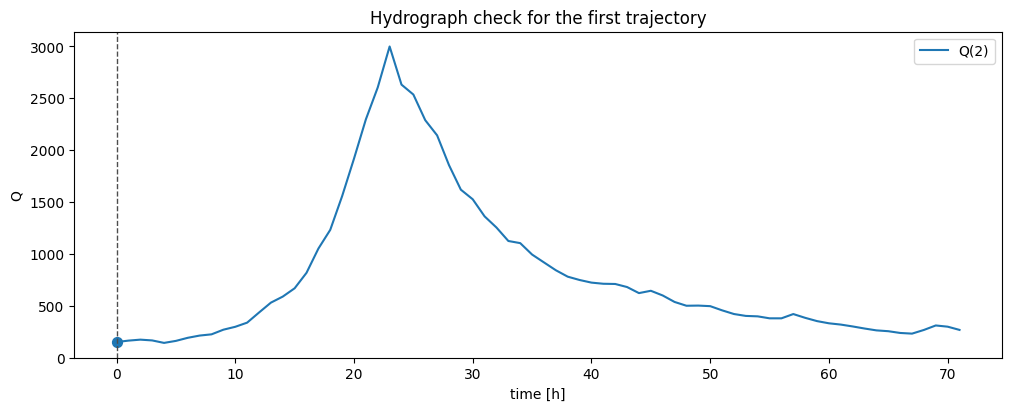

sample ts: 0
sample time [h]: 0.0
raw source features:
 [[149.27]]


In [9]:
sample_hydro = str(hydro_files[0])
_, _, ts = unpack_dynamic_sample(dataset.sequences[SAMPLE_INDEX][TIME_INDEX])
raw_source_features = dataset._build_source_features_raw(sample_hydro, ts)
time_hours = ts * DT_SECONDS / 3600.0

t_sec, q_values, q_labels = load_liq_q_series(sample_hydro)

fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)
for source_id, label in enumerate(q_labels):
    ax.plot(t_sec / 3600.0, q_values[:, source_id], label=label)
    ax.scatter([time_hours], [raw_source_features[source_id, 0]], s=50)

ax.axvline(time_hours, color="0.3", linestyle="--", linewidth=1.0)
ax.set_xlabel("time [h]")
ax.set_ylabel("Q")
ax.set_title("Hydrograph check for the first trajectory")
ax.legend(loc="best")
plt.show()

print("sample ts:", ts)
print("sample time [h]:", time_hours)
print("raw source features:\n", raw_source_features)
